# Empirical Mode Decomposition (EMD)
 
Data driven approach useful to extract "modes" from a signal. 
 
### Problem
 
It is difficult to get frequency information looking at temporal analysis of a signal (what is amplitude A of frequency F at time T).
 
It is difficult to get temporal information looking at frequency analysis of a signal.
 
We want to know: 

> When does event with a certain frequency occurs in the signal

### Solution

The EMD provides a potential solution to that problem. 

### Algorithm

This notebook contains the general algorithm behind the EMD. 

Variants exist but are not covered by this notebook. 

<IPython.core.display.Javascript object>


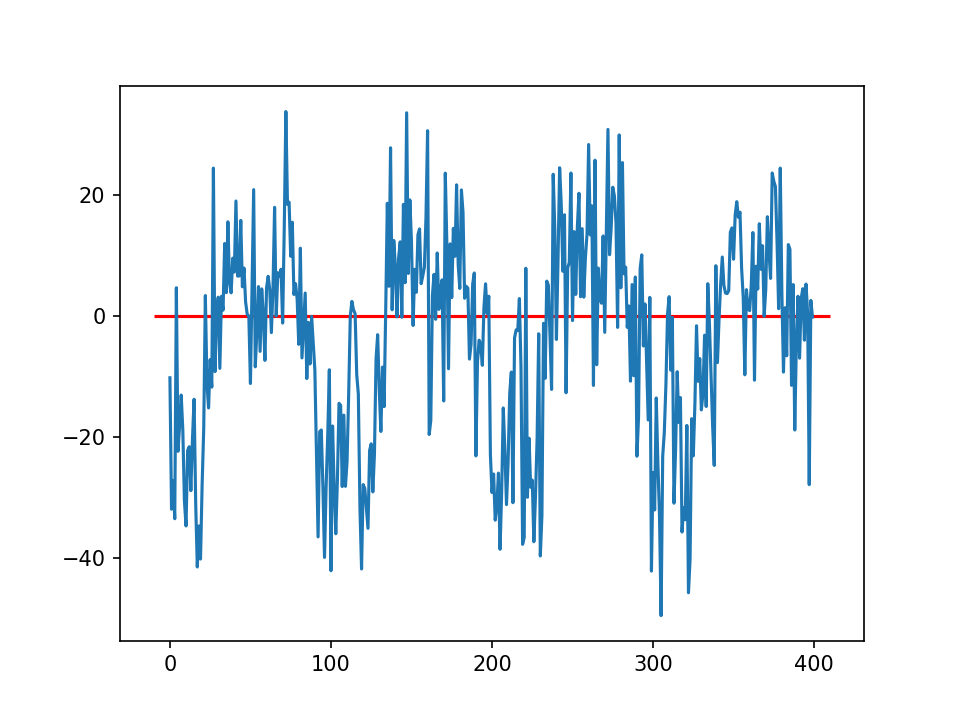

In [83]:
# 1. Get a "random" signal 
#
# Data comes from amplitudes of subcarrier 0, stream 0 for ~1 minute of data (with a bunch of missing packets)
# the goal was only to get a typical WiFi signal, not perfect data.

import matplotlib.pyplot as plt
%matplotlib notebook

import numpy as np

amplitudes = np.asarray([113.99122773266372, 92.26592003551474, 97.02061636580135, 90.68627239003708, 128.87590930814028, 101.83319694480774, 105.99056561788883, 111.13955191559843, 105.41821474489122, 93.64827814754524, 89.49301648732151, 101.9803902718557, 102.59142264341595, 95.33624704172071, 103.87011119662864, 110.44002897500525, 93.26306878931231, 82.71033792700887, 89.49860334105779, 84.02380615040002, 96.317184344228, 105.65036677645753, 127.58134659894448, 113.07077429645558, 109.00458705944443, 117.00427342623003, 112.44998888394787, 148.66068747318505, 115.0173899895142, 125.22779244241272, 127.3184982632139, 115.55085460523432, 127.47156545677157, 125.1758762701504, 136.19104228986575, 128.06248474865697, 139.7855500400524, 129.634100452003, 128.03515142334936, 133.76471881628578, 131.47243057006287, 143.22011031974526, 130.8166656049603, 130.8166656049603, 140.0142849854971, 129.0310040261642, 132.13629327327143, 126.50691680694776, 124.48293055676348, 124.2014492669067, 113.05308487608819, 128.65846260545786, 145.09651959988565, 115.80155439371269, 121.6552506059644, 129.0658746532173, 118.35962149314267, 128.69343417595164, 124.39051410778879, 116.86744627996283, 128.87590930814028, 130.77079184588584, 128.56126943990557, 121.45781160551181, 128.7866452703851, 142.1724305201258, 124.1933975700802, 131.36590120727678, 130.728726758888, 131.93938001976514, 123.03657992645927, 138.7984149765407, 158.00316452527144, 142.66744548074027, 143.0314650697531, 134.08206442324789, 139.71399357258383, 127.76932339180638, 129.55307792561317, 127.03542812932147, 119.5198728245642, 135.41787178950938, 117.27744881263405, 122.80065146407001, 128.00390619039717, 113.86395390991831, 123.14625451064275, 116.27553482998907, 124.14507642270796, 119.75391434103521, 115.25623627379127, 101.86265262597475, 87.69264507357501, 105.07616285342742, 105.3612832116238, 95.96353474106714, 84.29116205154607, 96.0260381354974, 104.5609869884557, 115.31261856362468, 82.09750300709517, 106.01886624558857, 95.77055915050303, 88.20430828479978, 97.082439194738, 109.7679370308106, 109.4440496326776, 96.02083107326243, 107.82393055347222, 96.04165762834376, 100.17983829094555, 111.28791488746656, 124.16923934694937, 126.62148316932637, 125.21980673998823, 124.59534501738017, 114.49017425089369, 111.30588483993108, 92.45539465060976, 82.37718130647589, 96.33275663033837, 95.70788891204319, 92.35799911215054, 89.10667763978185, 101.9803902718557, 103.07764064044152, 95.12623192369179, 101.35580891098448, 117.08543888972702, 121.1156472137271, 111.94641575325224, 105.11898020814318, 115.76268828944843, 109.22453936730518, 125.25573839150046, 142.84257068535277, 129.1239714383042, 152.0131573252789, 125.23977004130916, 136.7040599250805, 132.45754036671525, 124.06449935416659, 133.76471881628578, 136.4734406395618, 124.00403219250575, 142.6639407839276, 129.71121771072848, 157.8005069700348, 131.24404748406687, 143.4015341619468, 136.48809471891678, 122.64175471673585, 131.93938001976514, 128.1327436684316, 137.6154061142865, 138.6001443000692, 129.55307792561317, 130.8166656049603, 132.2800060477773, 140.45995870709916, 154.8418548067673, 104.62313319720452, 106.94391053257777, 127.56566936288148, 131.0953851209111, 123.664869708418, 134.6291201783626, 125.29964086141668, 128.57682528356344, 130.18832512940628, 110.16351483136329, 147.82760229402356, 135.67977004697494, 115.48592987892508, 136.12494260788506, 127.251719045363, 138.70832707519762, 134.08206442324789, 145.89036979869508, 132.69890730522238, 128.76334882255898, 145.0551619212498, 141.36477637657833, 127.1416532848303, 129.1239714383042, 128.80993750483694, 117.08543888972702, 119.50732195141852, 129.46814279968643, 131.3202193114221, 101.07917688624102, 116.70903992407786, 120.20815280171308, 119.4361754243663, 116.05602095539895, 125.67418191498204, 129.52219886953742, 124.61942063739504, 127.47548783981962, 101.31633629380802, 95.02105029939419, 98.08159868191383, 90.44888059008801, 92.77930803794561, 98.2344135219425, 85.63293758829018, 95.12623192369179, 109.00458705944443, 101.95096860746347, 93.02150289046077, 100.04498987955368, 111.40017953306898, 114.93476410555685, 93.34345183246653, 120.60265337047937, 121.91800523302537, 121.80722474467596, 127.09445306542689, 115.80155439371269, 86.45229898620394, 87.6184911990614, 132.09844813622905, 94.2443632266673, 104.0, 95.90099061010788, 97.082439194738, 86.88498144098322, 94.41398201537736, 103.81714694596457, 121.26417442921878, 84.52810183601665, 91.2414379544733, 123.0, 113.89907813498755, 129.9730741346068, 129.29423807734048, 121.01652779682617, 112.0714058089752, 147.63468427168462, 138.53880322855397, 120.33287165193059, 133.52153384379613, 148.71785366928881, 142.66744548074027, 131.60547101089682, 140.9432509913121, 111.5212984142491, 132.1854757528224, 133.06013678032951, 147.85127662620977, 123.45444503945575, 138.15932831336434, 127.76932339180638, 138.92443989449805, 144.49913494550754, 127.39309243440164, 138.6542462386205, 127.3184982632139, 133.843191832831, 137.7425134081704, 152.55490814785344, 137.6154061142865, 142.42541907960108, 112.72976536833562, 149.96666296213968, 116.15506876585283, 132.13629327327143, 127.06297651164952, 126.3210196285638, 137.43725841270262, 121.51131634543344, 138.13037319865606, 155.05160431288675, 134.33167906342868, 138.7984149765407, 145.49914089093448, 144.05901568454507, 139.61733416735902, 122.3315167894194, 154.14927829866735, 128.87590930814028, 149.56603892595405, 131.18307817702708, 132.2800060477773, 122.3315167894194, 125.8729518204765, 113.43720729989786, 129.40247292845683, 114.33722053644648, 130.64838307457157, 101.01980003939822, 107.5174404457249, 132.06059215375342, 134.31678971744373, 119.25183436744275, 126.21014222319853, 116.3486140871476, 107.01868995647442, 127.283148923964, 82.03657720797473, 98.35141076771599, 92.13576938409967, 110.65260954898443, 99.86490875177326, 91.35097153287424, 74.67261881037788, 101.0, 104.9952379872535, 112.8716084761797, 124.53513560437472, 127.40486646906389, 115.25623627379127, 123.96773773849388, 93.26306878931231, 102.07840124139877, 115.0, 106.60675400742676, 110.72488428533127, 88.48163651289458, 92.5418824100742, 90.52071586106685, 106.10372283760829, 78.44743462982075, 84.0535543567314, 107.2240644631605, 101.07917688624102, 109.65856099730654, 122.58874336577564, 113.4063490286148, 117.17508267545622, 108.67382389517726, 111.42710621747295, 121.03718436910205, 109.2520022699813, 129.55307792561317, 123.06502346320826, 114.47707194019246, 106.10372283760829, 99.50376877284599, 132.51792331605563, 116.49892703368559, 123.76186811776881, 129.52219886953742, 133.9589489358587, 129.28263611173776, 128.00390619039717, 127.91403363196706, 128.39003076563228, 138.06158046321215, 138.77319625922004, 133.60014970051492, 140.8900280360537, 143.10835055998655, 140.52757736472938, 141.36477637657833, 132.09844813622905, 127.3184982632139, 114.49017425089369, 128.56515857727553, 125.31959144523253, 125.09996003196804, 129.34063553268942, 138.00362314084367, 113.601470508735444, 132.43866504914644, 128.65846260545786, 139.46325680981354, 131.93938001976514, 135.83077707206124, 124.1491039033307, 128.65846260545786, 140.61649974309557, 134.8332303254654, 130.41855696180662, 147.85127662620977, 146.48549416239138, 145.60219778561037, 136.48809471891678, 125.41929676090518, 148.66068747318505, 128.06248474865697, 114.93476410555685, 125.57467897629681, 117.63077828527702, 136.01470508735443, 135.2479205015737, 112.75194011634566, 129.40247292845683, 105.3612832116238, 119.57006314291216, 127.47548783981962, 117.23907198540937, 127.13772060250254, 128.7245120402482, 120.20815280171308, 129.49517365523704, 124.61942063739504, 96.33275663033837, 126.77933585565118, 124.04031602668546, 111.0, 101.13851887386922, 108.67382389517726, 113.84638773364749, 107.2240644631605, 108.23123393919151, 108.85311203635843, 93.40770846134703, 109.0, 108.81176406988355, 124.27791436936813, 111.8257573191436, 91.28526715741155, 93.04837451562494, 86.34813257969161, 93.40770846134703, 97.14422267947796, 114.94781424629178, 90.08884503644167, 107.37783756436893, 98.85848471426213, 99.76472322419383, 96.16652224137046, 95.1892851112981, 99.90495483208028, 104.546640309481, 90.13878188659973, 88.23264701911646, 83.24061508662703, 87.66413177577246, 82.34682750416071, 111.19802156513397, 101.07917688624102, 127.06297651164952, 103.32473082471591, 122.3315167894194, 105.1094667477673, 121.10326172320876, 101.84301645179212, 111.30588483993108, 115.12167476196652, 133.15029102484155, 129.6919426949878, 144.77914214416384, 128.65457628860312, 128.41339493993607, 127.66362050325849, 127.251719045363, 133.5440002396214, 132.45754036671525, 123.08127396155761, 140.00357138301865, 143.40502083260543, 133.1465358167459, 140.6627171641441, 121.43310915891102, 137.3608386695422, 145.89036979869508, 138.7984149765407, 140.8900280360537, 141.15594213493105, 125.60254774486066, 127.76932339180638, 129.55307792561317, 128.65457628860312, 115.52056094046635, 117.33712115098103, 129.37542270462347, 120.90492132250036, 115.00434774390054, 17.72004514666935, 113.77170122662314, 119.54915307102765, 130.64838307457157, 137.27709204379295, 128.191263352851, 132.00378782444085, 142.68847185389575, 144.58907289280197, 144.22205101855957, 139.34489585198304, 146.64924138910504, 131.70041761513136, 127.88275880665071, 134.33167906342868, 152.0131573252789, 148.4082207965583, 146.86047800548656, 143.54441821262157, 132.00378782444085, 127.06297651164952, 138.00362314084367, 115.74541027617467, 124.96399481450646, 123.97580409095961, 134.5362404707371, 109.65856099730654, 113.8859078200635, 125.4312560727987, 145.7737973711325, 125.0, 15.620499351813308, 100.68763578513501, 123.71337841963576, 106.04244433244644, 104.92378186092989, 121.03718436910205, 112.58774356030055, 112.6454615153225, 113.46365056704283, 115.16944039110375, 94.13288479590966, 97.0, 88.20430828479978, 101.04454463255303, 86.31338250816034, 92.19544457292888, 88.84255736976509, 100.68763578513501, 100.31948963187563, 98.00510190801293, 148.8388390172404, 134.5362404707371, 123.79418403139947, 129.46814279968643, 121.03718436910205, 122.70289320142373, 117.74548823628021, 98.08159868191383, 93.86160024205851, 94.06912352095134, 116.69190203266035, 91.60785992479029, 107.05606008068857, 108.2081327812286, 65.52098900352466, 101.1236866416568, 98.67117106835208, 119.81652640600127, 114.9086593777858, 125.31959144523253, 90.82400563727631, 87.32124598286491, 93.40770846134703, 92.26592003551474, 103.07764064044152, 114.58621208504974, 112.60994627474076, 112.27199116431488, 87.46427842267951, 106.47065323364932, 112.94689017409908, 131.55227098001768, 128.76334882255898, 120.83045973594572, 122.6906679417795, 113.21660655575224, 116.70903992407786, 82.365041127896, 137.7534028617805, 115.6027681329474, 127.03542812932147, 129.46814279968643, 134.6142637315972, 134.1044369139217, 144.80676779764127, 147.35331689514152, 120.50311199301038, 120.74767078498864, 127.1927670899568, 115.73245007343446, 139.61733416735902, 133.76471881628578, 141.77799547179387, 142.13022197970423, 130.61393493804556, 128.0, 139.20488497175666, 137.13132391981054, 161.19863522995473, 142.89856542317, 140.46351839534705, 127.76932339180638, 130.5450113945378, 130.41855696180662, 134.7145129523913, 132.60844618650805, 146.98639392814562, 113.6001760562016, 129.0310040261642, 136.8575902169843, 130.23056476879765, 129.83836104942176, 142.8355697996826, 122.15563842901399, 146.2908062729849, 132.1854757528224, 104.5609869884557, 120.9297316626478, 140.52757736472938, 124.39051410778879, 142.6639407839276, 127.1927670899568, 132.00378782444085, 125.80143083447024, 134.7145129523913, 128.7245120402482, 114.79111463872106, 131.24404748406687, 130.728726758888, 134.08206442324789, 130.0, 118.35962149314267, 95.90099061010788, 121.64292005702592, 97.04638066409278, 103.07764064044152, 98.2700361249552, 91.92388155425118, 97.16480844420988, 93.00537618869137, 108.16653826391968, 85.0235261559999, 101.13851887386922, 112.44554237496477, 97.082439194738, 110.6752004741803, 95.29428104561154, 90.13878188659973, 112.11155159036913, 112.61438629233834, 100.24470060806208, 107.05606008068857, 97.082439194738, 118.10588469674151, 102.17631819555841, 94.25497334358543, 46.69047011971501, 107.5174404457249, 114.54693361238441, 104.9952379872535, 97.6165969494942, 103.3537614216338, 79.40403012442127, 80.77747210701756, 105.80170130957252, 119.25183436744275, 109.00458705944443, 106.66770832824712, 94.86832980505137, 101.07917688624102, 132.2800060477773, 105.94810050208545, 120.0, 118.51160280748886, 99.28242543370907, 125.0, 121.63058825805291, 142.22517358048822, 111.31936040060597, 125.7179382586272, 109.22453936730518, 117.90250209389112, 126.56223765404908, 135.41787178950938, 119.57006314291216, 120.70211265756701, 137.41906709041507, 141.40014144264495, 128.01562404644207, 117.72000679578642, 128.2692480682724, 128.89142717807107, 140.45995870709916, 128.00390619039717, 133.24038426843418, 141.76741515595182, 129.76902558006668, 138.06158046321215, 130.92364186807515, 144.03124660989366, 128.06248474865697, 127.39309243440164, 128.41339493993607, 129.1239714383042, 133.22537295875736, 143.17821063276352, 142.84257068535277, 136.69308687713507, 134.18271125595876, 120.20815280171308, 128.03515142334936, 124.65151423067431, 121.8400590938793, 128.2692480682724, 130.04999038831184, 134.40610105199838, 130.728726758888, 122.06555615733703, 130.26895255585654, 136.12494260788506, 131.7269904006009, 145.4269576110289, 117.83462988442744, 130.41855696180662, 97.52948272189288, 128.03515142334936, 117.00427342623003, 114.76933388322858, 110.3177229641729, 135.28118864054971, 118.96217886370441, 118.94956914591998, 124.33824833895642, 114.16216536138407, 108.07404868885037, 114.28035701729323, 95.58765610684259, 104.58011283222064, 92.66067126888301, 105.3612832116238, 106.23088063270491, 91.7877987534291, 101.07917688624102, 86.05230967266364, 89.88882021697692, 106.15083607772479, 86.81589716175259, 95.1892851112981, 123.01625908797584, 99.04039579888602, 112.27199116431488, 95.88013350011565, 121.24768039018313, 135.14806694880988, 106.89246933250256, 105.8158778255891, 83.60023923410746, 95.81753492967766, 101.71037311896953, 82.97590011563598, 76.21679604916491, 83.6301381082203, 87.82368700982668, 83.48652585896721, 73.06161783043132, 77.10382610480494, 88.64536084872124, 86.58521813797087, 106.56922632730333, 119.9208072020865, 108.40664186294121, 103.31021246711285, 98.29038610159185, 88.60022573334675, 103.00485425454472, 102.0, 120.20815280171308, 128.06248474865697, 114.80853626799707, 108.00462953040486, 125.93649193144932, 101.11874208078342, 133.70115930686615, 119.70797801316336, 118.51160280748886, 130.09611831257686, 116.1077086157504, 96.40020746865642, 130.728726758888, 120.93386622447825, 82.28000972289685, 135.07405376311175, 154.85799947048264, 135.95587519485872, 128.47178678604885, 131.24404748406687, 130.9083648969767, 20.615528128088304, 139.98928530426892, 145.7737973711325, 114.73883387938018, 131.84839779079607, 129.634100452003, 118.33849753989612, 135.36986370680884, 129.28263611173776, 122.9186723000212, 124.19742348374221, 129.634100452003, 128.4445405612866, 114.12712210513327, 129.83836104942176, 123.7457069962429, 107.07474025184464, 139.20129309744217, 137.7679207943562, 136.12494260788506, 155.90060936378666, 128.65846260545786, 124.78781991845197, 129.2594290564522, 138.19189556555045, 129.634100452003, 128.06248474865697, 134.7145129523913, 144.9413674559475, 139.08630414242805, 102.42070103255493, 121.69634341261039, 128.03515142334936, 95.12623192369179, 95.67131231461184, 118.20744477400736, 109.32977636490436, 128.3627671873741, 97.49871794028884, 107.01868995647442, 139.12943613772032, 100.80178569846865, 112.29425630903836, 102.1077861869505, 99.02019995940222, 110.0, 111.4136436887332, 110.67971810589327, 100.43903623591775, 94.72592042308166, 117.00427342623003, 111.25196627475849])
amplitudes = amplitudes[0:400]

center = np.median(amplitudes)
amplitudes = amplitudes - center

plt.hlines(y=0, xmin=-10, xmax=len(amplitudes)+ 10, colors='red')
plt.plot(amplitudes)

<IPython.core.display.Javascript object>


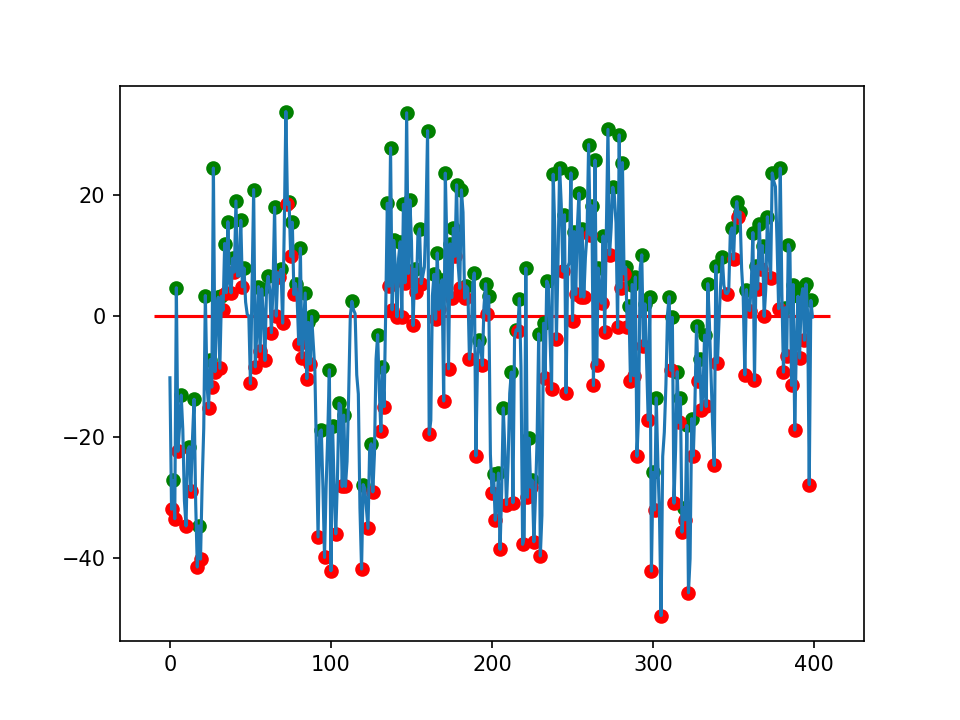

In [90]:
plt.close()
%matplotlib notebook

# 2 Find local extremas
from scipy.signal import argrelextrema

def find_extremas(values):
    maximas = argrelextrema(amplitudes, np.greater)
    minimas = argrelextrema(amplitudes, np.less)
    return maximas, minimas

maximas, minimas = find_extremas(values=amplitudes)

# Plot the maximas
plt.plot(maximas[0].tolist(), amplitudes[maximas[0]], 'go')

# Plot the minimas
plt.plot(minimas[0].tolist(), amplitudes[minimas[0]], 'ro')

plt.hlines(y=0, xmin=-10, xmax=len(amplitudes)+ 10, colors='red')
plt.plot(amplitudes)

<IPython.core.display.Javascript object>


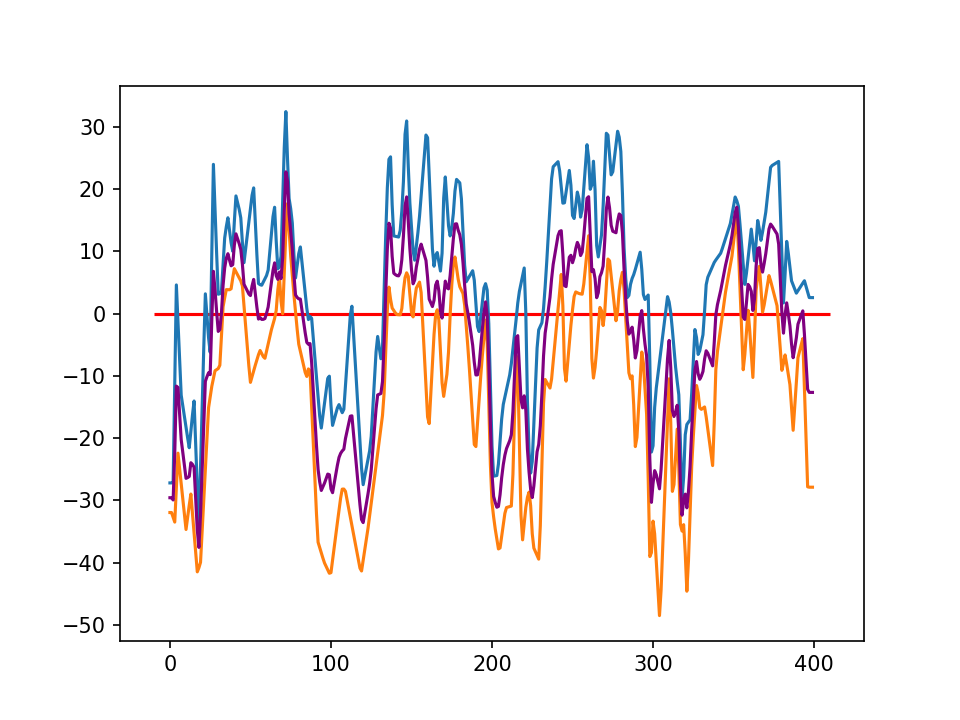

In [92]:
plt.close()
%matplotlib notebook        

# 3. Interpolate the extremas
def interpolate_extremas(maxs, mins, yvalues):
    space = np.linspace(0, len(yvalues), num=len(yvalues))
    ymaxs = np.interp(space, maxs, yvalues[maxs])
    ymins = np.interp(space, mins, yvalues[mins])
    return ymaxs, ymins
    
interpolated_maxs, interpolated_mins = interpolate_extremas(maximas[0], minimas[0], amplitudes) 
    
# Plot the interpolation
plt.hlines(y=0, xmin=-10, xmax=len(amplitudes)+ 10, colors='red')
plt.plot(ymaxs)
plt.plot(ymins)

# 4. Take the mean 
ymean = (ymaxs + ymins) / 2
plt.plot(ymean, color='purple')

<IPython.core.display.Javascript object>


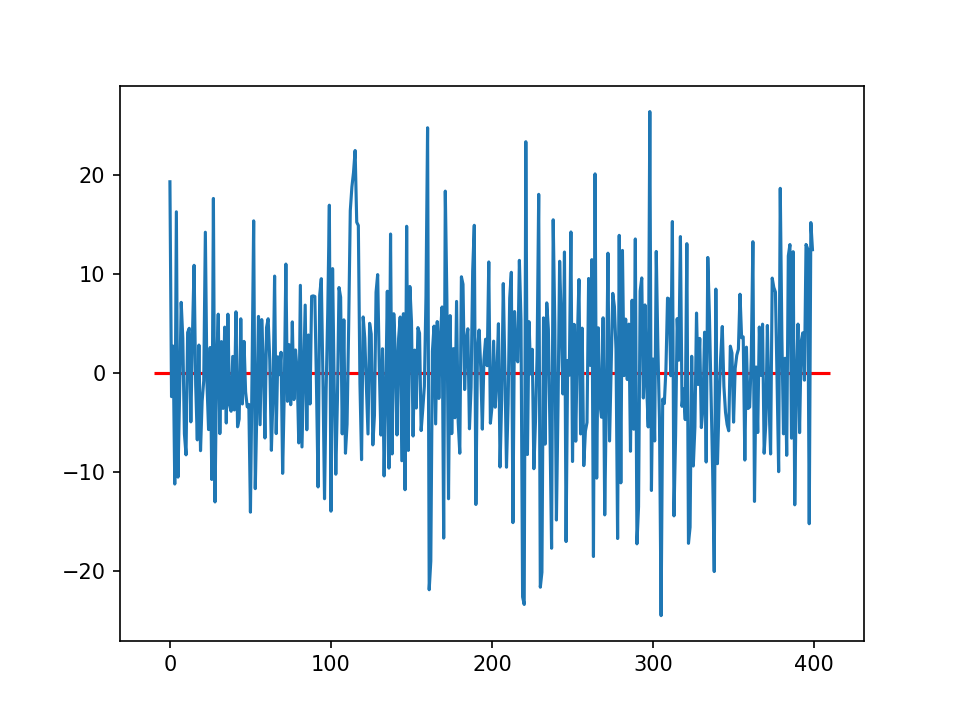

0.4102796006941837


In [94]:
plt.close()
%matplotlib notebook 

# 5. Compute the residue
new_amplitudes = amplitudes - ymean

plt.hlines(y=0, xmin=-10, xmax=len(new_amplitudes)+ 10, colors='red')
plt.plot(new_amplitudes)

# 6. Decide whether the residue is an IMF based on:
#    - 
#    - 

if np.mean(new_amplitudes) < 0.1e-3 && 


